# Q4 · When should EVs charge?

Solar pushed the cheapest electricity of the day from the night to midday (Q1, Q2). This notebook shows where the
cheap hours are now and what that is worth to an electric car.

Reads two dbt marts ([ADR-008](../control-room/04%20Decisions/ADR-008%20EV%20Charging%20Strategies.md)):

- `fct_hourly_profile`: mean and median day-ahead price and share of time at or below 0, per zone, local year,
  season and local hour of day.
- `fct_ev_charging`: one EV needing **10 kWh a day at 7 kW** (1 h 26 min of charging), priced every day under
  three strategies: **immediate** (plug in at 18:00 and charge), **overnight** (cheapest block between 22:00 and
  07:00) and **smart** (cheapest block at any time of the day).

**Wholesale component only.** Retail margins, taxes and grid fees are excluded, so the euro figures are not a
household bill: they show what timing alone changes. Day-ahead prices are published around noon the day before,
so a smart charger can know them in advance.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

import chart_style as cs

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    profile = con.sql("select * from fct_hourly_profile").df()
    ev = con.sql("select * from fct_ev_charging order by zone, local_year, season").df()
    ytd = con.sql("select * from fct_ytd_comparison order by zone, local_year").df()
    monthly = con.sql('''
        select zone, month(ts_local) as month, hour(ts_local) as local_hour,
               sum(price_eur_mwh * duration_h) / sum(duration_h) as mean_price
        from int_prices_local where local_year = 2025
        group by zone, month, local_hour''').df()

WHOLESALE = "Wholesale day-ahead price only: no retail margin, taxes or grid fees."
IT_NOTE = "North Italy: offers below 0 €/MWh are not allowed on its day-ahead market (GME), so prices cannot go negative."
ORDER = ["DE_LU", "NL", "BE", "FR", "ES", "PT", "PL", "IT_NORD"]
pct = mticker.PercentFormatter(1.0, decimals=0)
ev_year = ev[ev.season == "year"]
ev_year[ev_year.local_year == 2025]

,zone,local_year,season,days,immediate_eur_per_year,overnight_eur_per_year,smart_eur_per_year,overnight_savings_eur_per_year,smart_savings_eur_per_year,overnight_savings_share,smart_savings_share,immediate_price_eur_mwh,overnight_price_eur_mwh,smart_price_eur_mwh,is_partial_year,partial_reason,data_through_date
34,BE,2025,year,365,415.83,261.35,115.97,154.47,299.86,0.371486,0.721109,113.93,71.60,31.77,False,NaN,2025-12-31
74,DE_LU,2025,year,365,469.11,284.66,131.13,184.45,337.97,0.393196,0.720464,128.52,77.99,35.93,False,NaN,2025-12-31
114,ES,2025,year,365,271.11,229.64,89.00,41.47,182.11,0.152966,0.671713,74.28,62.91,24.38,False,NaN,2025-12-31
154,FR,2025,year,365,307.38,163.19,87.03,144.19,220.35,0.469088,0.716866,84.21,44.71,23.84,False,NaN,2025-12-31
194,IT_NORD,2025,year,365,507.04,373.80,308.83,133.24,198.21,0.262773,0.390908,138.92,102.41,84.61,False,NaN,2025-12-31
234,NL,2025,year,365,451.09,275.53,118.45,175.56,332.64,0.389186,0.737414,123.59,75.49,32.45,False,NaN,2025-12-31
272,PL,2025,year,365,547.33,325.64,179.46,221.69,367.87,0.405034,0.672112,149.95,89.22,49.17,False,NaN,2025-12-31
312,PT,2025,year,365,347.49,230.24,95.76,117.25,251.73,0.337427,0.724411,95.20,63.08,26.24,False,NaN,2025-12-31


## Chart 1 · Average price by hour of day and month, 2025
One panel per zone, same colour scale for all. Light = cheap. A dot marks a cell whose average was at or below 0.

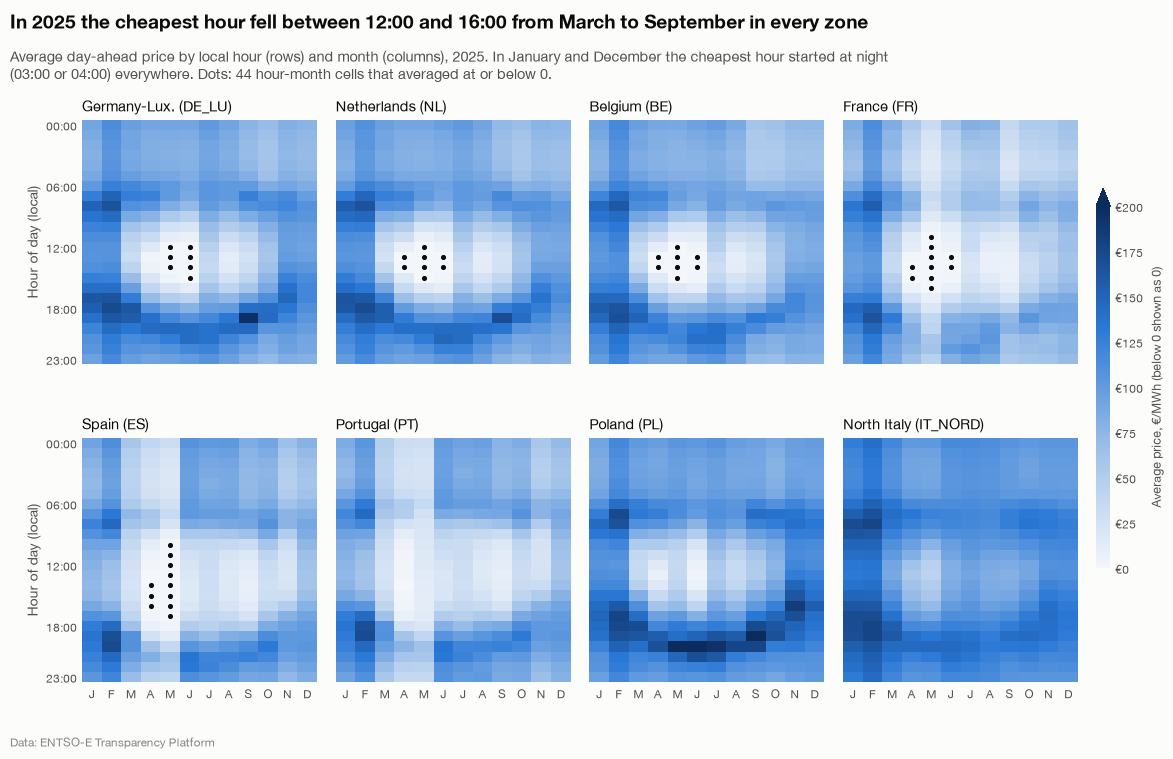

In [2]:
MONTHS = "JFMAMJJASOND"
cmap = LinearSegmentedColormap.from_list("price", ["#f3f6fb", "#9cbfe8", "#2a78d6", "#0d2c5e"])
vmin, vmax = 0, 200

fig, axes = plt.subplots(2, 4, figsize=(12, 7.6), sharex=True, sharey=True)
fig.subplots_adjust(left=0.07, right=0.9, top=0.84, bottom=0.1, hspace=0.3, wspace=0.08)
for ax, zone in zip(axes.flat, ORDER):
    grid = monthly[monthly.zone == zone].pivot(index="local_hour", columns="month", values="mean_price")
    image = ax.imshow(grid.to_numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto",
                      extent=(0.5, 12.5, 23.5, -0.5), interpolation="nearest")
    hours, months = np.where(grid.to_numpy() <= 0)
    ax.scatter(grid.columns[months], grid.index[hours], s=7, color=cs.INK, zorder=3)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.grid(False)
    ax.set_xticks(range(1, 13), list(MONTHS))
    ax.set_yticks([0, 6, 12, 18, 23], ["00:00", "06:00", "12:00", "18:00", "23:00"])
    ax.tick_params(length=0, labelsize=8.5)
    ax.spines["bottom"].set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Hour of day (local)")
cax = fig.add_axes([0.915, 0.25, 0.012, 0.5])
bar = fig.colorbar(image, cax=cax, extend="max")
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=8.5)
bar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.0f}"))
bar.set_label("Average price, €/MWh (below 0 shown as 0)", color=cs.INK_SECONDARY, fontsize=9)

cheapest = monthly.loc[monthly.groupby(["zone", "month"]).mean_price.idxmin()]
mid = cheapest[cheapest.month.between(3, 9)]
assert mid.local_hour.between(12, 15).all(), mid
winter = cheapest[cheapest.month.isin([1, 12])]
cs.add_title(
    fig,
    "In 2025 the cheapest hour fell between 12:00 and 16:00 from March to September in every zone",
    f"Average day-ahead price by local hour (rows) and month (columns), 2025. In January and December the cheapest "
    f"hour started at night\n({' or '.join(f'{h:02d}:00' for h in sorted(winter.local_hour.unique()))}) everywhere. "
    f"Dots: {int((monthly.mean_price <= 0).sum())} hour-month cells that averaged at or below 0.",
)
cs.add_source(fig)
cs.save(fig, "q4_price_by_hour_and_month_2025")
plt.show()

## Chart 2 · The cheapest hour of the day, 2019 vs 2025
Cheapest local hour on average over the whole year (duration-weighted mean price by hour, from `fct_hourly_profile`).
Poland uses 2020 instead of 2019 (its 2019 prices before 20 Nov are in PLN and left out).

         local_hour_early  mean_price_early  local_hour_2025  mean_price_2025
zone                                                                         
DE_LU                   3         27.733534               13        45.986110
NL                      4         32.006027               13        42.411616
BE                      4         28.099151               13        41.210521
FR                      4         27.246384               14        31.460849
ES                      4         40.496548               14        27.344082
PT                      3         40.821370               13        29.732849
PL                      3         37.404098               12        62.387781
IT_NORD                 4         40.042329               13        91.366685


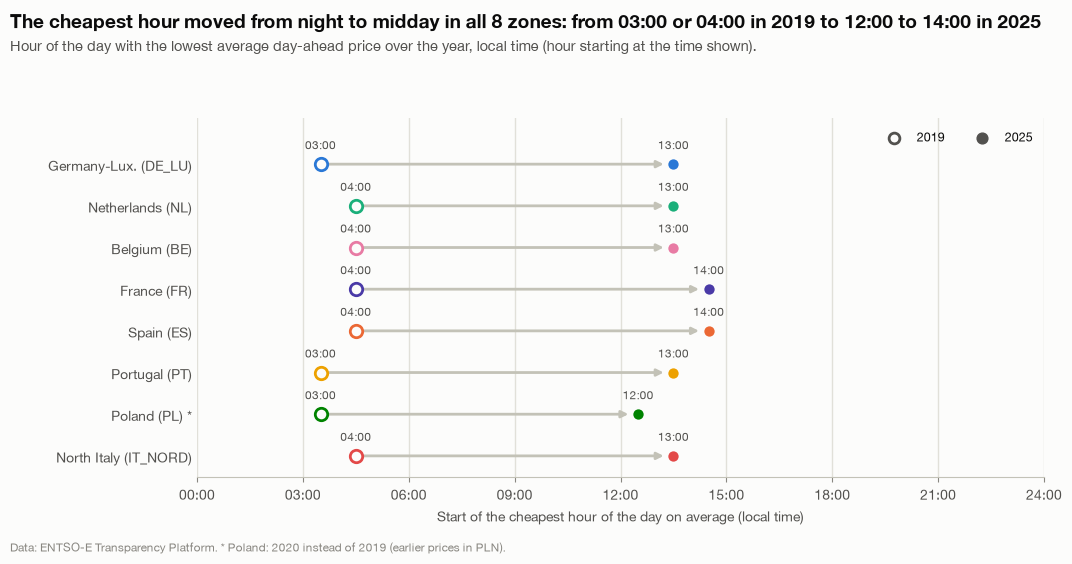

In [3]:
def cheapest_hour(year: int) -> pd.DataFrame:
    p = profile[profile.local_year == year].assign(w=lambda d: d.mean_price * d.covered_hours)
    by_hour = p.groupby(["zone", "local_hour"]).agg(w=("w", "sum"), h=("covered_hours", "sum"))
    by_hour["mean_price"] = by_hour.w / by_hour.h
    by_hour = by_hour.reset_index()
    return by_hour.loc[by_hour.groupby("zone").mean_price.idxmin(), ["zone", "local_hour", "mean_price"]]

early = pd.concat([cheapest_hour(2019).query("zone != 'PL'"), cheapest_hour(2020).query("zone == 'PL'")])
late = cheapest_hour(2025)
c2 = early.merge(late, on="zone", suffixes=("_early", "_2025")).set_index("zone").loc[ORDER]
print(c2)

fig, ax = plt.subplots(figsize=(11, 5.6))
fig.subplots_adjust(left=0.18, right=0.95, top=0.79, bottom=0.15)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
for i, (zone, r) in enumerate(c2.iterrows()):
    color = cs.ZONE_COLORS[zone]
    ax.annotate("", xy=(r.local_hour_2025 + 0.5, i), xytext=(r.local_hour_early + 0.5, i),
                arrowprops={"arrowstyle": "-|>", "color": cs.AXIS, "lw": 2, "shrinkA": 6, "shrinkB": 7})
    ax.scatter(r.local_hour_early + 0.5, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.scatter(r.local_hour_2025 + 0.5, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    ax.text(r.local_hour_early + 0.5, i - 0.3, f"{int(r.local_hour_early):02d}:00", ha="center", va="bottom",
            fontsize=8.5, color=cs.INK_SECONDARY)
    ax.text(r.local_hour_2025 + 0.5, i - 0.3, f"{int(r.local_hour_2025):02d}:00", ha="center", va="bottom",
            fontsize=8.5, color=cs.INK_SECONDARY)
labels = [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "PL" else "") for z in c2.index]
ax.set_yticks(range(len(c2)), labels)
ax.set_ylim(len(c2) - 0.5, -1.1)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3), [f"{h:02d}:00" for h in range(0, 25, 3)])
ax.set_xlabel("Start of the cheapest hour of the day on average (local time)")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label="2019")
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label="2025")
ax.legend(loc="upper right", frameon=False, fontsize=9, ncol=2)

cs.add_title(
    fig,
    f"The cheapest hour moved from night to midday in all 8 zones: from {c2.local_hour_early.min():02d}:00 or "
    f"{c2.local_hour_early.max():02d}:00 in 2019 to {c2.local_hour_2025.min():02d}:00 to "
    f"{c2.local_hour_2025.max():02d}:00 in 2025",
    "Hour of the day with the lowest average day-ahead price over the year, local time (hour starting at the "
    "time shown).",
)
cs.add_source(fig, "* Poland: 2020 instead of 2019 (earlier prices in PLN).")
cs.save(fig, "q4_cheapest_hour_2019_vs_2025")
plt.show()

## Chart 3 · What smart charging saves, 2025
Wholesale cost per year of charging 10 kWh a day: immediate (18:00) minus smart (cheapest block of the day).
The tick shows the saving from charging overnight (22:00 to 07:00) instead.

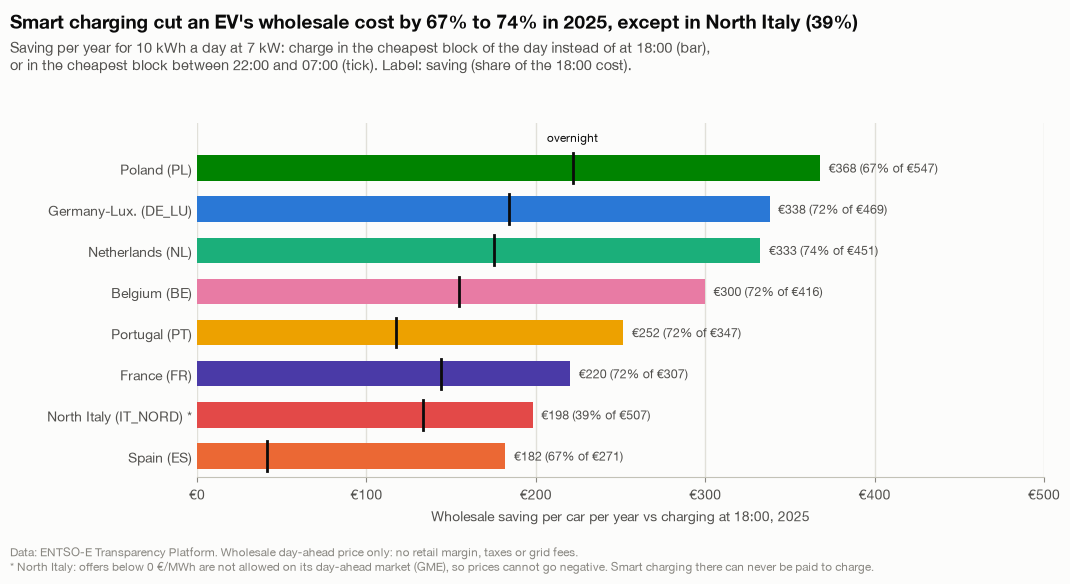

In [4]:
c3 = ev_year[ev_year.local_year == 2025].sort_values("smart_savings_eur_per_year", ascending=False)
c3 = c3.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.subplots_adjust(left=0.18, right=0.95, top=0.79, bottom=0.18)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
for i, r in c3.iterrows():
    ax.barh(i, r.smart_savings_eur_per_year, height=0.62, color=cs.ZONE_COLORS[r.zone], zorder=2)
    ax.plot([r.overnight_savings_eur_per_year] * 2, [i - 0.36, i + 0.36], color=cs.INK, lw=2, zorder=3)
    ax.text(r.smart_savings_eur_per_year + 5, i,
            f"€{r.smart_savings_eur_per_year:.0f} ({r.smart_savings_share:.0%} of €{r.immediate_eur_per_year:.0f})",
            ha="left", va="center", fontsize=9, color=cs.INK_SECONDARY)
ax.set_yticks(range(len(c3)), [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "IT_NORD" else "") for z in c3.zone])
ax.set_ylim(len(c3) - 0.5, -1.1)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.0f}"))
ax.set_xlim(0, 500)
ax.set_xlabel("Wholesale saving per car per year vs charging at 18:00, 2025")
ax.spines["bottom"].set_color(cs.AXIS)
top = c3.iloc[0]
ax.annotate("overnight", (top.overnight_savings_eur_per_year, -0.36), xytext=(0, 6), textcoords="offset points",
            ha="center", va="bottom", fontsize=8.5, color=cs.INK)

others = c3[c3.zone != "IT_NORD"]
it = c3.set_index("zone").loc["IT_NORD"]
cs.add_title(
    fig,
    f"Smart charging cut an EV's wholesale cost by {others.smart_savings_share.min():.0%} to "
    f"{others.smart_savings_share.max():.0%} in 2025, except in North Italy ({it.smart_savings_share:.0%})",
    "Saving per year for 10 kWh a day at 7 kW: charge in the cheapest block of the day instead of at 18:00 (bar),\n"
    "or in the cheapest block between 22:00 and 07:00 (tick). Label: saving (share of the 18:00 cost).",
)
cs.add_source(fig, WHOLESALE + "\n* " + IT_NOTE + " Smart charging there can never be paid to charge.")
cs.save(fig, "q4_smart_charging_savings_2025")
plt.show()

## By season
The same comparison per season, 2025 (€ per year at that season's prices).

In [5]:
s25 = ev[(ev.local_year == 2025) & (ev.season != "year")]
s25.pivot(index="zone", columns="season", values="smart_savings_share")[["winter", "spring", "summer", "autumn"]].round(3)

season,winter,spring,summer,autumn
zone,,,,
BE,0.454,1.003,0.884,0.642
DE_LU,0.451,0.940,0.881,0.679
ES,0.549,0.833,0.672,0.796
FR,0.505,0.913,0.887,0.768
IT_NORD,0.298,0.545,0.349,0.386
NL,0.476,1.002,0.876,0.675
PL,0.422,0.851,0.807,0.629
PT,0.574,0.822,0.766,0.827


In [6]:
s25.pivot(index="zone", columns="season", values="overnight_savings_share")[["winter", "spring", "summer", "autumn"]].round(3)

season,winter,spring,summer,autumn
zone,,,,
BE,0.429,0.303,0.172,0.528
DE_LU,0.417,0.349,0.186,0.552
ES,0.420,0.159,-0.528,0.223
FR,0.475,0.423,0.299,0.632
IT_NORD,0.287,0.281,0.172,0.301
NL,0.441,0.329,0.158,0.555
PL,0.381,0.368,0.331,0.516
PT,0.453,0.508,-0.027,0.396


## Over time: smart and overnight savings share
Full years (2019 to 2025) in the first two tables; 2026 to date only next to the same window of 2025 in the last one.

In [7]:
ev_year[ev_year.local_year < 2026].pivot(index="zone", columns="local_year", values="smart_savings_share").round(3)

local_year,2019,2020,2021,2022,2023,2024,2025
zone,,,,,,,
BE,0.471,0.565,0.488,0.500,0.549,0.685,0.721
DE_LU,0.490,0.606,0.506,0.490,0.582,0.694,0.720
ES,0.221,0.301,0.282,0.280,0.419,0.517,0.672
FR,0.453,0.514,0.447,0.391,0.518,0.667,0.717
IT_NORD,0.366,0.440,0.332,0.344,0.373,0.389,0.391
NL,0.384,0.549,0.474,0.515,0.634,0.730,0.737
PL,0.341,0.296,0.368,0.471,0.412,0.621,0.672
PT,0.240,0.336,0.317,0.345,0.477,0.584,0.724


In [8]:
ev_year[ev_year.local_year < 2026].pivot(index="zone", columns="local_year", values="overnight_savings_share").round(3)

local_year,2019,2020,2021,2022,2023,2024,2025
zone,,,,,,,
BE,0.443,0.481,0.432,0.377,0.414,0.455,0.371
DE_LU,0.429,0.497,0.439,0.382,0.409,0.446,0.393
ES,0.198,0.268,0.221,0.171,0.172,0.148,0.153
FR,0.432,0.473,0.414,0.358,0.411,0.501,0.469
IT_NORD,0.348,0.415,0.316,0.302,0.305,0.313,0.263
NL,0.368,0.486,0.417,0.365,0.417,0.442,0.389
PL,0.350,0.296,0.358,0.404,0.342,0.457,0.405
PT,0.223,0.306,0.262,0.248,0.291,0.289,0.337


In [9]:
# Like for like: 1 Jan to the as-of date in 2025 and 2026.
ytd[ytd.local_year.isin([2025, 2026])].pivot(index="zone", columns="local_year",
    values=["ev_smart_saving_share", "ev_overnight_saving_share"]).round(4)

ev_smart_saving_share         ev_overnight_saving_share        
local_year                  2025    2026                      2025    2026
zone                                                                      
BE                        0.7868  0.7449                    0.3326  0.2688
DE_LU                     0.7815  0.7903                    0.3582  0.2696
ES                        0.6712  0.7751                    0.0406 -0.3486
FR                        0.7363  0.8259                    0.4202  0.2980
IT_NORD                   0.4052  0.4202                    0.2488  0.2119
NL                        0.8026  0.7789                    0.3488  0.2635
PL                        0.7334  0.7719                    0.3933  0.3386
PT                        0.7353  0.8325                    0.2900  0.1029

## Numbers quoted in the findings

In [10]:
cols = ["zone", "local_year", "days", "immediate_eur_per_year", "overnight_eur_per_year", "smart_eur_per_year",
        "overnight_savings_eur_per_year", "smart_savings_eur_per_year", "overnight_savings_share",
        "smart_savings_share", "immediate_price_eur_mwh", "overnight_price_eur_mwh", "smart_price_eur_mwh"]
ev_year[ev_year.local_year.isin([2019, 2025, 2026])][cols].sort_values(["local_year", "zone"])

,zone,local_year,days,immediate_eur_per_year,overnight_eur_per_year,smart_eur_per_year,overnight_savings_eur_per_year,smart_savings_eur_per_year,overnight_savings_share,smart_savings_share,immediate_price_eur_mwh,overnight_price_eur_mwh,smart_price_eur_mwh
4,BE,2019,364,175.90,97.96,93.13,77.93,82.77,0.443070,0.470564,48.19,26.84,25.51
44,DE_LU,2019,364,173.05,98.78,88.19,74.26,84.85,0.429150,0.490355,47.41,27.06,24.16
84,ES,2019,364,183.03,146.72,142.50,36.31,40.52,0.198360,0.221412,50.14,40.20,39.04
124,FR,2019,364,175.06,99.44,95.77,75.63,79.29,0.431995,0.452920,47.96,27.24,26.24
164,IT_NORD,2019,364,222.54,145.13,140.99,77.41,81.55,0.347857,0.366461,60.97,39.76,38.63
204,NL,2019,364,179.29,113.28,110.38,66.00,68.91,0.368147,0.384326,49.12,31.04,30.24
242,PL,2019,42,188.70,122.66,124.42,66.04,64.28,0.349974,0.340648,51.70,33.61,34.09
282,PT,2019,365,189.51,147.27,144.02,42.24,45.50,0.222900,0.240065,51.92,40.35,39.46
34,BE,2025,365,415.83,261.35,115.97,154.47,299.86,0.371486,0.721109,113.93,71.60,31.77
74,DE_LU,2025,365,469.11,284.66,131.13,184.45,337.97,0.393196,0.720464,128.52,77.99,35.93


## Check: no en or em dashes in chart text
Same house style as Q1 to Q3: ranges use "to"; negative numbers use the real minus sign.

In [11]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q4_*.svg"))
assert len(svgs) == 3, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 3 SVGs: q4_cheapest_hour_2019_vs_2025.svg, q4_price_by_hour_and_month_2025.svg, q4_smart_charging_savings_2025.svg
